In [1]:
# Import von Bibliotheken
import io,re
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from collections import Counter
!pip install spacy
!python -m spacy download de_core_news_sm
import spacy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 44.0 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')


**AUSSCHLIEßLICH WAHLPROGRAMME**

In [2]:
# Einlesen der Langwahlprogramme (aus JSON-Format in ein Wörterbuch)

# für CDU/CSU
with open("cdu-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    CDU_text_json = json.load(datei)

# für SPD
with open("spd-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    SPD_text_json = json.load(datei)

# für Die Linke
with open("linke-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    Linke_text_json = json.load(datei)

# für die AfD
with open("afd-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    AfD_text_json = json.load(datei)

# für Bündnis 90/Grüne
with open("gruene-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    Grüne_text_json = json.load(datei)

# für FDP
with open("fdp-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    FDP_text_json = json.load(datei)

In [3]:
# Überführen aller 'eigentlichen' Texte in eine Liste pro Partei, d.h. ohne Kapitelüberschriften

# Suchfunktion in den "Partei-Wörterbüchern"

def finde_gefilterte_texte(struktur):
    ergebnisse = []
    
    # Fall A: Wenn das aktuelle Element ein Dictionary ist
    if isinstance(struktur, dict):
        # Typ/Art auslesen (liefert None, wenn der Schlüssel fehlt)
        aktueller_typ = struktur.get('type') or struktur.get('art')            # nur Suchen in diesen Elementen
        
        # Prüfen, ob 'text' existiert und der gefundene Typ gültig ist
        if 'text' in struktur and aktueller_typ in ['paragraph', 'bullet', 'absatz']:   # nur Texte überführen mit diesem Typ
            ergebnisse.append(struktur['text'])
        
        # Tiefer in alle Werte schauen für eventuelle Verschachtelungen
        for wert in struktur.values():
            ergebnisse.extend(finde_gefilterte_texte(wert))
                
    # Fall B: Wenn das aktuelle Element eine Liste ist
    elif isinstance(struktur, list):
        for element in struktur:
            ergebnisse.extend(finde_gefilterte_texte(element))
            
    return ergebnisse

CDU_text = finde_gefilterte_texte(CDU_text_json)
SPD_text = finde_gefilterte_texte(SPD_text_json)
Linke_text = finde_gefilterte_texte(Linke_text_json)
Grüne_text = finde_gefilterte_texte(Grüne_text_json)
AfD_text = finde_gefilterte_texte(AfD_text_json)
FDP_text = finde_gefilterte_texte(FDP_text_json)

In [4]:
# Überführen aller 'eigentlichen' Texte in einen String pro Partei, d.h. ohne Kapitelüberschriften

# für CDU/CSU
CDU_text_str = [text if text.endswith('.') else text + '.' for text in CDU_text]   # ein "Punkt" wird gesetzt bei Bulletpoints
CDU_text = " ".join(CDU_text_str)

# für SPD
SPD_text_str = [text if text.endswith('.') else text + '.' for text in SPD_text]
SPD_text = " ".join(SPD_text_str)

# für Die Linke
Linke_text_str = [text if text.endswith('.') else text + '.' for text in Linke_text]
Linke_text = " ".join(Linke_text_str)

# für die AfD
AfD_text_str = [text if text.endswith('.') else text + '.' for text in AfD_text]
AfD_text = " ".join(AfD_text_str)

# für Bündnis 90/Grüne
Grüne_text_str = [text if text.endswith('.') else text + '.' for text in Grüne_text]
Grüne_text = " ".join(Grüne_text_str)

# für FDP
FDP_text_str = [text if text.endswith('.') else text + '.' for text in FDP_text]
FDP_text = " ".join(FDP_text_str)

In [5]:
# Bereinigen der Texte => Umformen von Abkürzungen in Text

def bereinige_abkuerzungen(text):
    # Dictionary mit den Top 20 Ersetzungen (Regex-Muster als Key)
    ersetzungen = {
        r'\bz\.\s*B\.': 'zum Beispiel',   # r'\bz\.\s*B\.\b': 'zum Beispiel',
        r'\bu\.\s*a\.': 'unter anderem',
        r'\bd\.\s*h\.': 'das heißt',
        r'\bbzw\.': 'beziehungsweise',
        r'\bbzw': 'beziehungsweise',   # Variante ohne Punkt
        r'\bsog\.': 'sogenannte',
        r'\bca\.': 'circa',
        r'\bevtl\.': 'eventuell',
        r'\binkl\.': 'inklusive',
        r'\betc\.': 'et cetera',
        r'\bvgl\.': 'vergleiche',
        r'\bs\.': 'siehe',
        r'\bu\.\s*v\.\s*m\.': 'und vieles mehr',
        r'\bu\.\s*ä\.': 'und ähnliche',
        r'\bggf\.': 'gegebenenfalls',
        r'\bzzgl\.': 'zuzüglich',
        r'\bebd\.': 'ebenda',
        r'\bo\.\s*g\.': 'oben genannte',
        r'\bu\.\s*g\.': 'unten genannte',
        r'\bi\.\s*d\.\s*R\.': 'in der Regel',
        r'\bv\.\s*a\.': 'vor allem',

        # 2. Titel & Personen (Verhindern Satzabbruch mitten im Fluss)
        r'\bDr\.': 'Doktor',
        r'\bProf\.': 'Professor',
        r'\bFr\.': 'Frau',
        r'\bHr\.': 'Herr',

        # 3. Wortlaengen- & Silben-Verfaelscher
        r'\bbspw\.': 'beispielsweise',
        r'\bbspw': 'beispielsweise',   # Variante ohne Punkt
        r'\bbsp\.': 'Beispiel',
        r'\bJh\.': 'Jahrhundert',
        r'\bMio\.': 'Millionen',
        r'\bMrd\.': 'Milliarden',
        r'\bbetr\.': 'betreffend',
        r'\bbezgl\.': 'bezüglich',
        r'\bvs\.': 'versus'
    }

    # Text Schritt für Schritt bereinigen
    for muster, ersetzung in ersetzungen.items():
        # flags=re.IGNORECASE sorgt dafür, dass auch "Z.B." oder "Bzw." gefunden werden
        text = re.sub(muster, ersetzung, text, flags=re.IGNORECASE)

    return text

CDU_text = bereinige_abkuerzungen(CDU_text)
SPD_text = bereinige_abkuerzungen(SPD_text)
Grüne_text = bereinige_abkuerzungen(Grüne_text)
AfD_text = bereinige_abkuerzungen(AfD_text)
Linke_text = bereinige_abkuerzungen(Linke_text)
FDP_text = bereinige_abkuerzungen(FDP_text)

In [6]:
# Modalverben zählen

# Modalverben Konjunktiv I nkl. Präsens
modalverben_1 = [
    "darf", "dürfe", "dürfen", "kann", "könne", "können", "mag", "möge", "mögen", "muss", "müsse", "müssen",
    "müsse", "müssen", "solle", "sollen", "wolle", "wollen"
]

# Modalverben Konjunktiv II inkl. Präteritum
modalverben_2 = [
    "durfte", "durften", "dürfte", "dürften",  # dürfen
    "konnte", "konnten", "könnte", "könnten",  # können
    "mochte", "mochten", "möchte", "möchten",  # mögen
    "musste", "mussten", "müsste", "müssten",  # müssen
    "sollte", "sollten",                       # sollen
    "wollte", "wollten"                        # wollen
]

# zusätzliche Untersuchung nach Wort-Kombi "wir wollen|wollen wir"
wir_wollen = [
    "wir wollen", "wollen wir"
]

In [7]:
# alle Wörter aus den jeweiligen Wahlprogramm-Texten extrahieren; vorher die Wörter noch klein schreiben

CDU_text_str_mod = re.findall(r'\b\w+\b', CDU_text.lower())
Linke_text_str_mod = re.findall(r'\b\w+\b', Linke_text.lower())
AfD_text_str_mod = re.findall(r'\b\w+\b', AfD_text.lower())
FDP_text_str_mod = re.findall(r'\b\w+\b', FDP_text.lower())
SPD_text_str_mod = re.findall(r'\b\w+\b', SPD_text.lower())
Grüne_text_str_mod = re.findall(r'\b\w+\b', Grüne_text.lower())

In [8]:
# zählen wie häufig die Modelverben-Gruppen 1 und 2 sowie 'wir wollen|wollen wir' in den Texten vorkommen

CDU_modal_1 = {verb: Counter(CDU_text_str_mod)[verb] for verb in modalverben_1}
Linke_modal_1 = {verb: Counter(Linke_text_str_mod)[verb] for verb in modalverben_1}
AfD_modal_1 = {verb: Counter(AfD_text_str_mod)[verb] for verb in modalverben_1}
FDP_modal_1 = {verb: Counter(FDP_text_str_mod)[verb] for verb in modalverben_1}
SPD_modal_1 = {verb: Counter(SPD_text_str_mod)[verb] for verb in modalverben_1}
Grüne_modal_1 = {verb: Counter(Grüne_text_str_mod)[verb] for verb in modalverben_1}

CDU_modal_2 = {verb: Counter(CDU_text_str_mod)[verb] for verb in modalverben_2}
Linke_modal_2 = {verb: Counter(Linke_text_str_mod)[verb] for verb in modalverben_2}
AfD_modal_2 = {verb: Counter(AfD_text_str_mod)[verb] for verb in modalverben_2}
FDP_modal_2 = {verb: Counter(FDP_text_str_mod)[verb] for verb in modalverben_2}
SPD_modal_2 = {verb: Counter(SPD_text_str_mod)[verb] for verb in modalverben_2}
Grüne_modal_2 = {verb: Counter(Grüne_text_str_mod)[verb] for verb in modalverben_2}

CDU_modal_3 = {"wir wollen": CDU_text.count("wir wollen")}
Linke_modal_3 = {"wir wollen": Linke_text.count("wir wollen")}
AfD_modal_3 = {"wir wollen": AfD_text.count("wir wollen")}
FDP_modal_3 = {"wir wollen": FDP_text.count("wir wollen")}
SPD_modal_3 = {"wir wollen": SPD_text.count("wir wollen")}
Grüne_modal_3 = {"wir wollen": Grüne_text.count("wir wollen")}

CDU_modal_4 = {"wollen wir": CDU_text.count("wollen wir")}
Linke_modal_4 = {"wollen wir": Linke_text.count("wollen wir")}
AfD_modal_4 = {"wollen wir": AfD_text.count("wollen wir")}
FDP_modal_4 = {"wollen wir": FDP_text.count("wollen wir")}
SPD_modal_4 = {"wollen wir": SPD_text.count("wollen wir")}
Grüne_modal_4 = {"wollen wir": Grüne_text.count("wollen wir")}

In [9]:
parteien = ["CDU/CSU", "SPD", "Grüne", "AfD", "Linke", "FDP"]

# Ergebnisse der "Modalverben"-Dictionaries pro Partei zusammenfassen
data = {
    "CDU/CSU": {**CDU_modal_1, **CDU_modal_2},
    "SPD": {**SPD_modal_1, **SPD_modal_2},
    "Grüne": {**Grüne_modal_1, **Grüne_modal_2},
    "AfD": {**AfD_modal_1, **AfD_modal_2},
    "Linke": {**Linke_modal_1, **Linke_modal_2},
    "FDP": {**FDP_modal_1, **FDP_modal_2},
}

# DataFrame erstellen
df = pd.DataFrame(data)

# Fehlende Werte mit 0 auffüllen, falls irgendwo bei der Suche kein Verb gefunden wurde
df = df.fillna(0).astype(int)

# "Verben"-Spalte benennen
df = df.reset_index().rename(columns={"index": "Verb"})

# Löschen alle Zeilen mit Anzahl < 5
df = df[(df.drop(columns="Verb") > 4).any(axis=1)]

# Löschen aller Verben, die bei allen Parteien weniger als 5 Mal vorkommen
summe = df.select_dtypes(include="number").sum()
df_sum = pd.DataFrame([summe])
df_sum.insert(0, "Verb", "Σ Modalverben")

df = pd.concat([df, df_sum], ignore_index=True)
print(df)

             Verb  CDU/CSU  SPD  Grüne  AfD  Linke  FDP
0            darf       18   20     16   36     40   18
1          dürfen       10    6     16   15     31   12
2            kann       27   31     55   38     34   27
3          können       56   87    164   47     96   60
4            muss       96   59     87   98    197   74
5          müssen       99   68    116   45    263   77
6          sollen       23   62     80   41     81   24
7          wollen      126  268    548   47    326  292
8         möchten        1    4     19    3      1    9
9          sollte        5    1     10    8      8   10
10        sollten        1    1      7    7     12    5
11  Σ Modalverben      462  607   1118  385   1089  608


In [10]:
# Anzahl alle Verben

# Einbindung Spacy
nlp = spacy.load("de_core_news_sm")

# Liste mit allen Wahlprogramm-Texten
texte = [
    CDU_text,
    SPD_text,
    Grüne_text,
    AfD_text,
    Linke_text,
    FDP_text
]

# Liste für die Anzahl der Verben
anzahl_verben = []

# Schleife über alle Texte und Erfassung aller Verben ("VERB") + Hilfsverben (letzere werden unter dem Tag "AUX" geführt)
for text in texte:
    doc = nlp(text)
    #verben = [token for token in doc if token.pos_ == "VERB"]
    verben = [token for token in doc if token.pos_ in ["VERB", "AUX"]]
    anzahl_verben.append(len(verben))

# Zeile benennen, d.h. in Indexspalte den folgenden Text einfügen
anzahl_verben.insert(0,"Summe aller Verben")
anzahl_verben

['Summe aller Verben', 3824, 3967, 6998, 3515, 5215, 2911]

In [11]:
# Vorbereitung weiterer Zeilen für Grafik, Summenziehung, Prozentberechnung der Anteile...

summe_row = pd.DataFrame([anzahl_verben], columns=df.columns, index=["12"])
summe_row
# Zeile anhängen
df_cat = pd.concat([df, summe_row], axis=0)

vorletzte = df_cat.iloc[-2,1:].astype(int)  # z. B. "können"
letzte = df_cat.iloc[-1,1:].astype(int)     # z. B. "Summe alle Verben"
anteil = (vorletzte / letzte*100).round(0).astype(int)

# Neue Zeile als DataFrame erstellen
neue_zeile = pd.DataFrame([["Anteil in %"] + list(anteil)], columns=df.columns)

# Zeile anhängen
df_gesamt = pd.concat([df_cat, neue_zeile], ignore_index=True)

print(df_gesamt)

                  Verb  CDU/CSU   SPD  Grüne   AfD  Linke   FDP
0                 darf       18    20     16    36     40    18
1               dürfen       10     6     16    15     31    12
2                 kann       27    31     55    38     34    27
3               können       56    87    164    47     96    60
4                 muss       96    59     87    98    197    74
5               müssen       99    68    116    45    263    77
6               sollen       23    62     80    41     81    24
7               wollen      126   268    548    47    326   292
8              möchten        1     4     19     3      1     9
9               sollte        5     1     10     8      8    10
10             sollten        1     1      7     7     12     5
11       Σ Modalverben      462   607   1118   385   1089   608
12  Summe aller Verben     3824  3967   6998  3515   5215  2911
13         Anteil in %       12    15     16    11     21    21


In [12]:
data_wollen = {
    "CDU/CSU": {**CDU_modal_3, **CDU_modal_4},
    "SPD": {**SPD_modal_3, **SPD_modal_4},
    "Grüne": {**Grüne_modal_3, **Grüne_modal_4},
    "AfD": {**AfD_modal_3, **AfD_modal_4},
    "Linke": {**Linke_modal_3, **Linke_modal_4},
    "FDP": {**FDP_modal_3, **FDP_modal_4},
}

df_wollen = pd.DataFrame(data_wollen)
df_wollen

,CDU/CSU,SPD,Grüne,AfD,Linke,FDP
wir wollen,0,4,13,0,2,2
wollen wir,45,117,334,26,110,159


In [13]:
# in LaTex überführen

latex_code = df_gesamt.to_latex(index=False, caption='Meine Übersicht', label='tab:meine_tabelle')
with open('tabelle_modalverben.tex', 'w') as f:
    f.write(latex_code)

latex_code = df_wollen.to_latex(index=False, caption='Meine Übersicht', label='tab:meine_tabelle')
with open('tabelle_modalverben_wollen.tex', 'w') as f:
    f.write(latex_code)

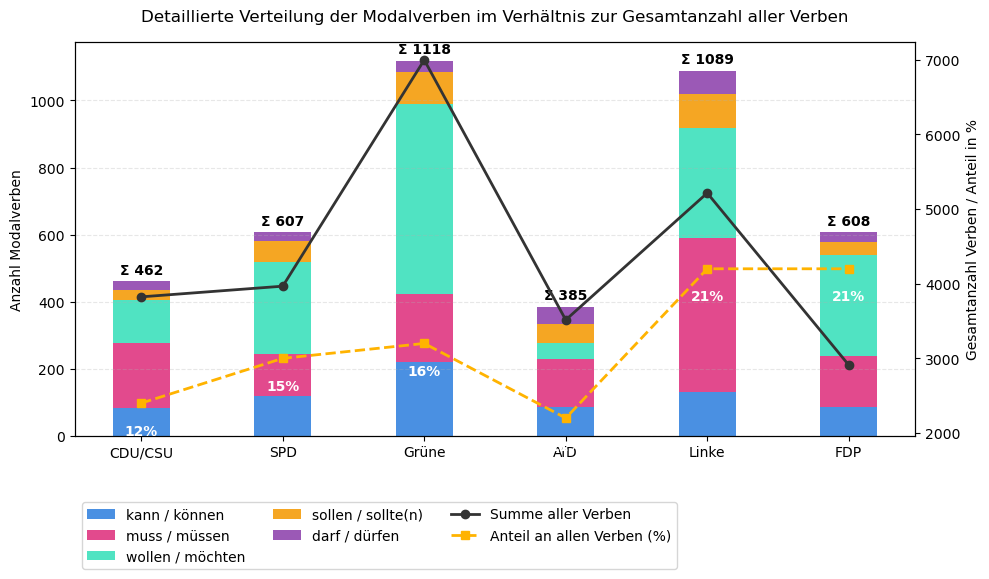

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Daten definieren
parties = ['CDU/CSU', 'SPD', 'Grüne', 'AfD', 'Linke', 'FDP']
darf_duerfen = np.array([28, 26, 32, 51, 71, 30])
koennen = np.array([83, 118, 219, 85, 130, 87])
muessen = np.array([195, 127, 203, 143, 460, 151])
sollen_sollte = np.array([29, 64, 97, 56, 101, 39])
wollen_moechten = np.array([127, 272, 567, 50, 327, 301])

sum_modal = np.array([462, 607, 1118, 385, 1089, 608])
sum_all = np.array([3824, 3967, 6998, 3515, 5215, 2911])
anteil = np.array([12, 15, 16, 11, 21, 21])

x = np.arange(len(parties))
width = 0.4

fig, ax1 = plt.subplots(figsize=(10, 6))

# Gestapelte Balken
ax1.bar(x, koennen, width, label='kann / können', color='#4A90E2')
ax1.bar(x, muessen, width, bottom=koennen, label='muss / müssen', color='#E24A8D')
ax1.bar(x, wollen_moechten, width, bottom=koennen+muessen, label='wollen / möchten', color='#50E3C2')
ax1.bar(x, sollen_sollte, width, bottom=koennen+muessen+wollen_moechten, label='sollen / sollte(n)', color='#F5A623')
ax1.bar(x, darf_duerfen, width, bottom=koennen+muessen+wollen_moechten+sollen_sollte, label='darf / dürfen', color='#9B59B6')

ax1.set_ylabel('Anzahl Modalverben')
ax1.set_xticks(x)
ax1.set_xticklabels(parties)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Summen-Beschriftung über den Balken
for i in range(len(parties)):
    ax1.annotate(f'Σ {sum_modal[i]}', xy=(x[i], sum_modal[i]), xytext=(0, 3),
                 textcoords="offset points", ha='center', va='bottom', fontweight='bold')

# Zweite Achse
ax2 = ax1.twinx()
ax2.set_ylabel('Gesamtanzahl Verben / Anteil in %')

# Linien (Anteil skaliert für visuelle Harmonie)
ax2.plot(x, sum_all, color='#333333', marker='o', linewidth=2, label='Summe aller Verben')
ax2.plot(x, anteil * 200, color='#FFB300', marker='s', linestyle='--', linewidth=2, label='Anteil an allen Verben (%)')     #    #2ECC71

for i in range(len(parties)):
    ax2.annotate(f'{anteil[i]}%', xy=(x[i], anteil[i]*200), xytext=(0, -15),
                 textcoords="offset points", ha='center', va='top', color='#FFFFFF', fontweight='bold')

# Gemeinsame Legende unten
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(0.0, -0.15), ncol=3)

plt.title('Detaillierte Verteilung der Modalverben im Verhältnis zur Gesamtanzahl aller Verben', pad=15)
fig.tight_layout()

# Wichtig für LaTeX: Als PDF speichern!
plt.savefig('modalverben_gesamtuebersicht_neu.pdf', bbox_inches='tight')


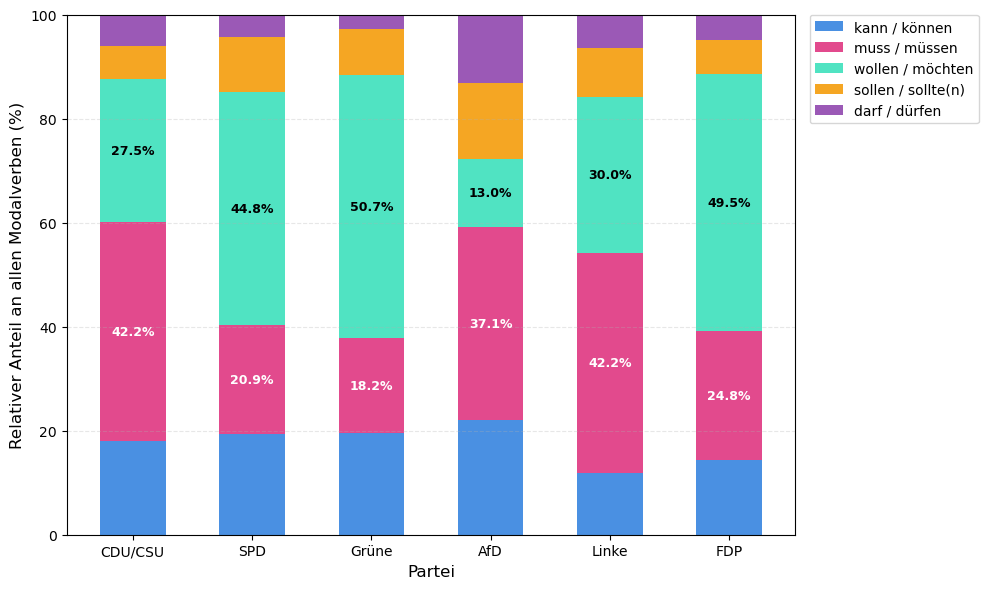

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Daten definieren
parties = ['CDU/CSU', 'SPD', 'Grüne', 'AfD', 'Linke', 'FDP']
koennen = np.array([83, 118, 219, 85, 130, 87])
muessen = np.array([195, 127, 203, 143, 460, 151])
wollen_moechten = np.array([127, 272, 567, 50, 327, 301])
sollen_sollte = np.array([29, 64, 97, 56, 101, 39])
darf_duerfen = np.array([28, 26, 32, 51, 71, 30])

# Gesamtsumme der Modalverben pro Partei zur Normierung
sum_modal = koennen + muessen + wollen_moechten + sollen_sollte + darf_duerfen

# Umrechnung in relative Anteile (Prozent)
p_koennen = (koennen / sum_modal) * 100
p_muessen = (muessen / sum_modal) * 100
p_wollen = (wollen_moechten / sum_modal) * 100
p_sollen = (sollen_sollte / sum_modal) * 100
p_darf = (darf_duerfen / sum_modal) * 100

x = np.arange(len(parties))
width = 0.55  # Etwas breitere Balken wirken stabiler bei 100%-Charts

fig, ax = plt.subplots(figsize=(10, 6))

# Gestapelte Balken (jetzt normiert auf 100%)
ax.bar(x, p_koennen, width, label='kann / können', color='#4A90E2')
ax.bar(x, p_muessen, width, bottom=p_koennen, label='muss / müssen', color='#E24A8D')
ax.bar(x, p_wollen, width, bottom=p_koennen+p_muessen, label='wollen / möchten', color='#50E3C2')
ax.bar(x, p_sollen, width, bottom=p_koennen+p_muessen+p_wollen, label='sollen / sollte(n)', color='#F5A623')
ax.bar(x, p_darf, width, bottom=p_koennen+p_muessen+p_wollen+p_sollen, label='darf / dürfen', color='#9B59B6')

# Kosmetik & Beschriftung
ax.set_ylabel('Relativer Anteil an allen Modalverben (%)', fontsize=12)
ax.set_xlabel('Partei', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(parties)
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Optionale Wertebeschriftung direkt in den markanten Balkensegmenten (z.B. für "muss" und "wollen")
for i in range(len(parties)):
    # Text in der Mitte des "muss"-Balkens platzieren
    ax.text(x[i], p_koennen[i] + p_muessen[i]/2, f'{p_muessen[i]:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    # Text in der Mitte des "wollen"-Balkens platzieren
    ax.text(x[i], p_koennen[i] + p_muessen[i] + p_wollen[i]/2, f'{p_wollen[i]:.1f}%', ha='center', va='center', color='black', fontweight='bold', fontsize=9)

# Legende clean platzieren
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

#plt.title('Proportionale Verteilung der Modalverben in den Wahlprogrammen', pad=15, fontsize=14, fontweight='bold')
fig.tight_layout()

# Export als PDF für LaTeX
plt.savefig('modalverben_verteilung_normiert.pdf', bbox_inches='tight')
plt.show()


In [4]:
# ENDE